Official references:
- InsightFace repo: https://github.com/deepinsight/insightface
- Face swap example: `examples/in_swapper/inswapper_main.py`
- PyPI install notes: https://pypi.org/project/insightface/


In [ ]:
!pip -q install insightface==0.7.3 onnxruntime==1.22.0 opencv-python-headless==4.10.0.84

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 14.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.6 MB/s eta 0:00:00


In [ ]:
import os
os.makedirs('/root/.insightface/models', exist_ok=True)
INSWAPPER_PATH = '/root/.insightface/models/inswapper_128.onnx'
if not os.path.exists(INSWAPPER_PATH):
    print('⬇ inswapper_128.onnx 다운로드 중... (~500MB)')
    !wget -q --show-progress \
        -O {INSWAPPER_PATH} \
        https://huggingface.co/ezioruan/inswapper_128.onnx/resolve/main/inswapper_128.onnx
    print('✅ 다운로드 완료')
else:
    print('✅ inswapper_128.onnx 이미 존재')

⬇ inswapper_128.onnx 다운로드 중... (~500MB)
/root/.insightface/ 100%[===================>] 528.58M   265MB/s    in 2.0s    
✅ 다운로드 완료


In [ ]:
import os
import cv2
import numpy as np
import insightface
from insightface.app import FaceAnalysis
from google.colab import files
from IPython.display import display, Image

print('insightface version:', insightface.__version__)

insightface version: 0.7.3


In [ ]:
uploaded = files.upload()

print('Uploaded files:')
for name in uploaded:
    print('-', name)

SOURCE_PATH = "/content/avatar.jpeg"
TARGET_PATH = "/content/스크린샷 2026-04-14 오후 11.08.43.png"

for name in uploaded:
    lower = name.lower()
    if SOURCE_PATH is None and ('source' in lower or 'face' in lower):
        SOURCE_PATH = name
    elif TARGET_PATH is None and ('target' in lower or 'avatar' in lower):
        TARGET_PATH = name

if SOURCE_PATH is None or TARGET_PATH is None:
    print('\nRename your files like: source.jpg and avatar.png, then rerun this cell if needed.')
    print('Current guess -> source:', SOURCE_PATH, 'target:', TARGET_PATH)
else:
    print('\nUsing source:', SOURCE_PATH)
    print('Using target:', TARGET_PATH)

Uploaded files:

Using source: /content/avatar.jpeg
Using target: /content/스크린샷 2026-04-14 오후 11.08.43.png


Source preview


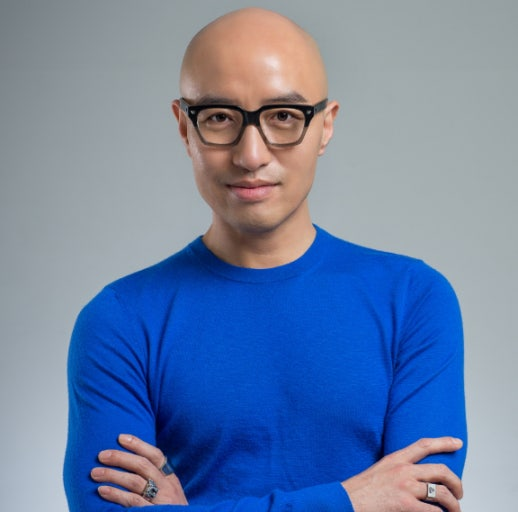

Target avatar preview


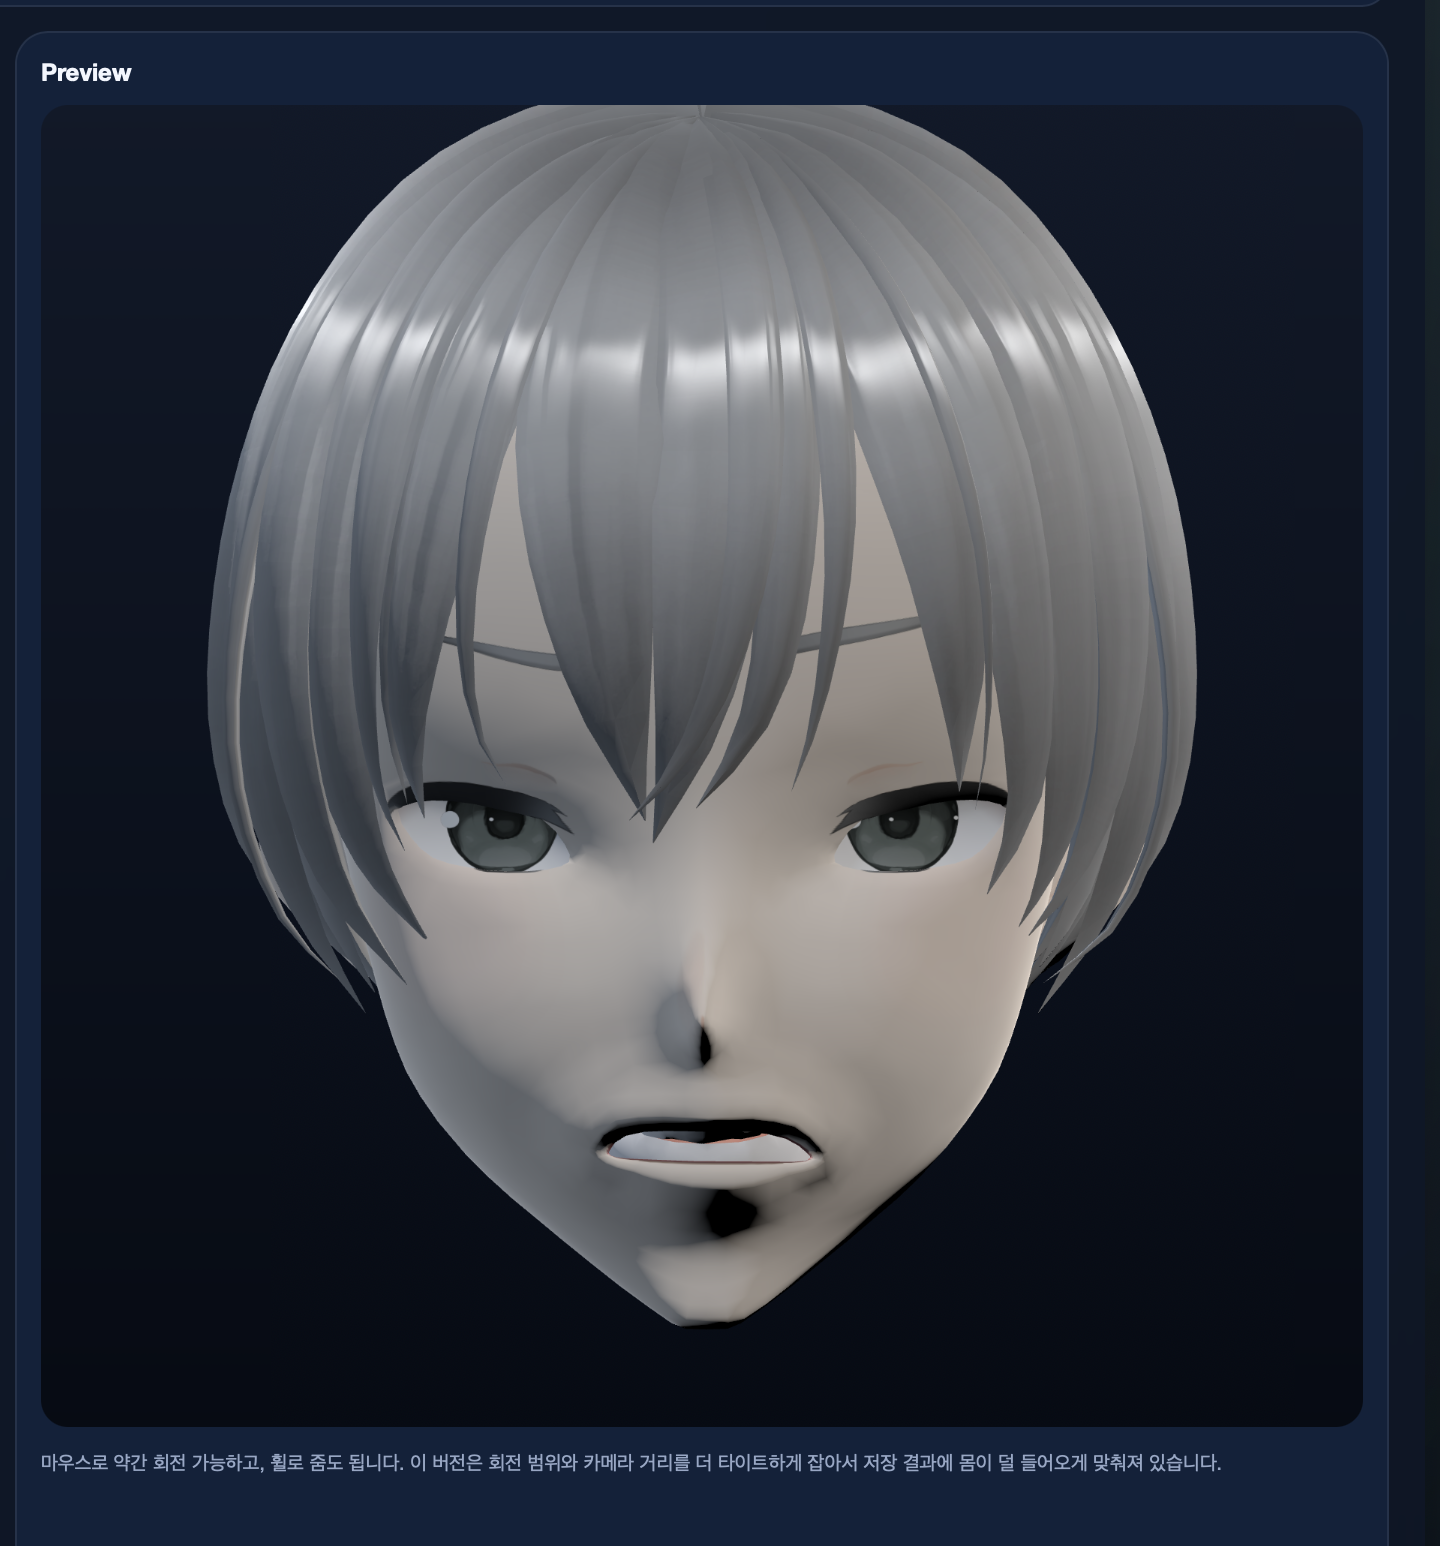

In [ ]:
if SOURCE_PATH and TARGET_PATH:
    print('Source preview')
    display(Image(filename=SOURCE_PATH, width=280))
    print('Target avatar preview')
    display(Image(filename=TARGET_PATH, width=280))

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Applied prov

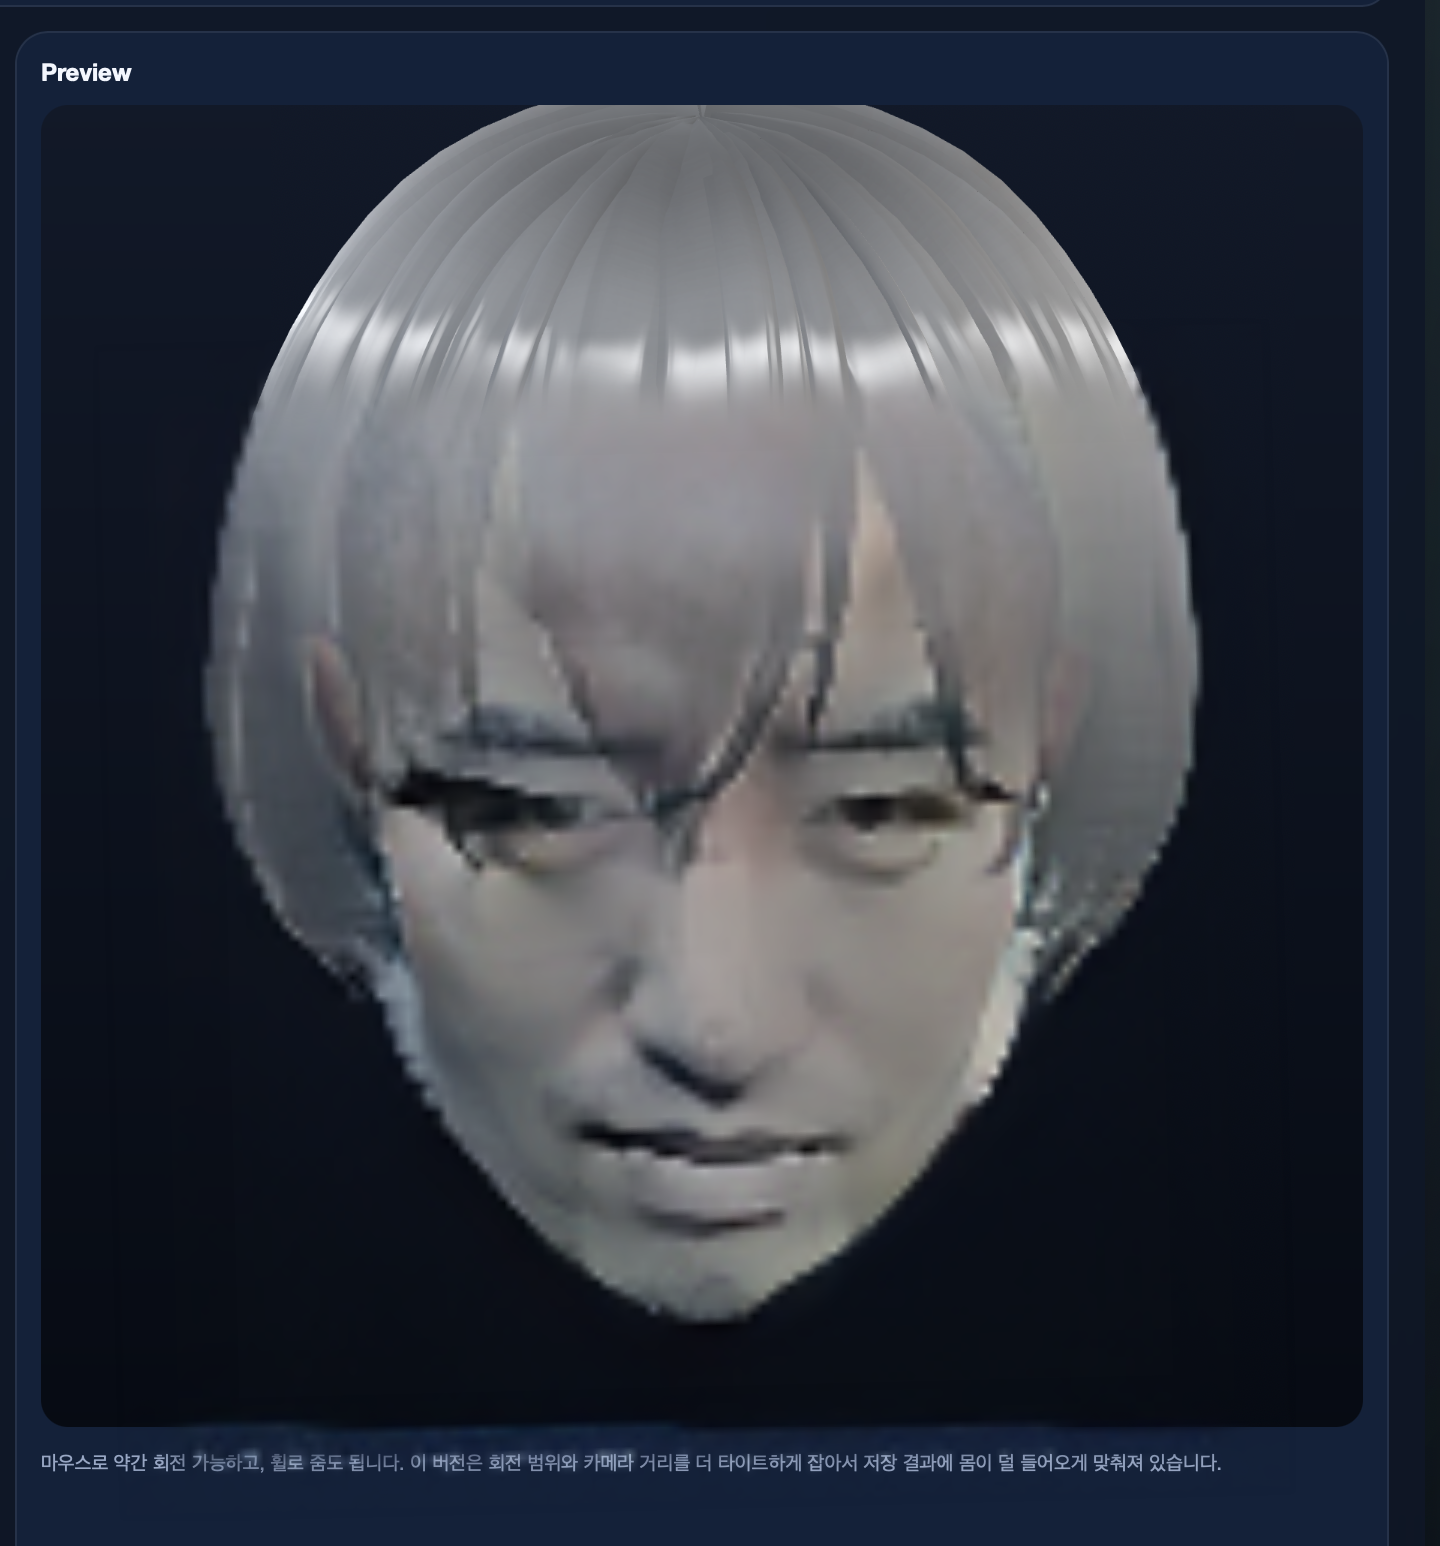

In [ ]:
if not SOURCE_PATH or not TARGET_PATH:
    raise ValueError('Please upload files named like source.jpeg and avatar.png first.')

app = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))
swapper = insightface.model_zoo.get_model('inswapper_128.onnx', download=True, download_zip=True)

source_img = cv2.imread(SOURCE_PATH)
target_img = cv2.imread(TARGET_PATH)

source_faces = app.get(source_img)
target_faces = app.get(target_img)

print('source faces:', len(source_faces))
print('target faces:', len(target_faces))

if len(source_faces) == 0:
    raise ValueError('No face found in source image.')
if len(target_faces) == 0:
    raise ValueError('No face found in target avatar image. Try a more realistic avatar or a larger face crop.')

source_face = sorted(source_faces, key=lambda x: (x.bbox[2] - x.bbox[0]) * (x.bbox[3] - x.bbox[1]), reverse=True)[0]
target_faces = sorted(target_faces, key=lambda x: x.bbox[0])

result = target_img.copy()
for face in target_faces:
    result = swapper.get(result, face, source_face, paste_back=True)

out_path = 'avatar_swapped.png'
cv2.imwrite(out_path, result)
print('Saved:', out_path)
display(Image(filename=out_path, width=420))

In [ ]:
files.download('avatar_swapped.png')

## Tips

- If your avatar is very stylized, crop tightly around the face and try again.
- If detection still fails, use a more human-like avatar render.
- For multiple faces in the target, this notebook swaps all detected faces with the same source face.
- For better speed in Colab GPU, you can replace `onnxruntime` with `onnxruntime-gpu`, but the CPU setup above is usually the simplest starting point.


#바꾸긱

In [ ]:
# 2) 파일 업로드
from google.colab import files
uploaded = files.upload()

print(list(uploaded.keys()))


Saving 화면 기록 2026-04-15 오전 12.06.54.mov to 화면 기록 2026-04-15 오전 12.06.54.mov
['화면 기록 2026-04-15 오전 12.06.54.mov']


In [ ]:
# 3) 입력 파일 지정
# 업로드한 파일명에 맞게 수정하세요.
SOURCE_IMAGE = "/content/ek.jpeg"
DRIVING_VIDEO = "/content/화면 기록 2026-04-15 오전 12.06.54.mov"

# 결과 파일명
OUTPUT_VIDEO = "inswapper_result.mp4"


In [ ]:
# 4) 프레임 추출 + FPS 확인
import os, json, subprocess, shlex
from pathlib import Path

frames_dir = Path("frames")
swapped_dir = Path("swapped_frames")
frames_dir.mkdir(exist_ok=True)
swapped_dir.mkdir(exist_ok=True)

def run(cmd):
    print(cmd)
    subprocess.run(cmd, shell=True, check=True)

# fps 확인
fps_cmd = f"ffprobe -v error -select_streams v:0 -show_entries stream=r_frame_rate -of default=nw=1:nk=1 {shlex.quote(DRIVING_VIDEO)}"
fps_raw = subprocess.check_output(fps_cmd, shell=True).decode().strip()
num, den = fps_raw.split("/")
FPS = float(num) / float(den)
print("FPS =", FPS)

# 프레임 추출
run(f"ffmpeg -y -i {shlex.quote(DRIVING_VIDEO)} {frames_dir}/frame_%06d.png")


FPS = 60.0
ffmpeg -y -i '/content/화면 기록 2026-04-15 오전 12.06.54.mov' frames/frame_%06d.png


In [ ]:
# 5) inswapper 로드
import cv2
import numpy as np
from tqdm import tqdm
from pathlib import Path
import insightface
from insightface.app import FaceAnalysis

providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]

app = FaceAnalysis(name="buffalo_l", providers=providers)
app.prepare(ctx_id=0, det_size=(640, 640))

swapper = insightface.model_zoo.get_model(
    "inswapper_128.onnx",
    download=True,
    download_zip=True,
    providers=providers,
)

print("models ready")


download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 86915.76KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:121: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Applied prov

In [ ]:
# 6) 소스 얼굴 준비
source_img = cv2.imread(SOURCE_IMAGE)
assert source_img is not None, f"source image not found: {SOURCE_IMAGE}"

source_faces = app.get(source_img)
assert len(source_faces) > 0, "소스 이미지에서 얼굴을 찾지 못했습니다."

# 가장 큰 얼굴 1개만 사용
source_face = max(
    source_faces,
    key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1])
)

print("source face loaded")


source face loaded


In [ ]:
# 7) 프레임별 face swap
frame_paths = sorted(frames_dir.glob("frame_*.png"))
print("frame count:", len(frame_paths))

for frame_path in tqdm(frame_paths):
    frame = cv2.imread(str(frame_path))
    if frame is None:
        continue

    target_faces = app.get(frame)

    # 얼굴 없으면 원본 그대로 저장
    if len(target_faces) == 0:
        cv2.imwrite(str(swapped_dir / frame_path.name), frame)
        continue

    # 가장 큰 얼굴 1개만 swap
    target_face = max(
        target_faces,
        key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1])
    )

    try:
        result = swapper.get(frame, target_face, source_face, paste_back=True)
    except Exception as e:
        print("swap failed on", frame_path.name, e)
        result = frame

    cv2.imwrite(str(swapped_dir / frame_path.name), result)

print("swap done")


frame count: 1001


100%|██████████| 1001/1001 [1:00:49<00:00,  3.65s/it]

swap done


In [ ]:
# 8) 영상으로 다시 합치기 + 원본 오디오 유지
run(
    f"ffmpeg -y "
    f"-framerate {FPS} "
    f"-i {swapped_dir}/frame_%06d.png "
    f"-i {shlex.quote(DRIVING_VIDEO)} "
    f"-map 0:v:0 -map 1:a? "
    f"-c:v libx264 -pix_fmt yuv420p "
    f"-c:a aac -shortest "
    f"{shlex.quote(OUTPUT_VIDEO)}"
)


ffmpeg -y -framerate 60.0 -i swapped_frames/frame_%06d.png -i '/content/화면 기록 2026-04-15 오전 12.06.54.mov' -map 0:v:0 -map 1:a? -c:v libx264 -pix_fmt yuv420p -c:a aac -shortest inswapper_result.mp4


In [ ]:
# 9) 결과 다운로드
files.download(OUTPUT_VIDEO)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>